**A data science experiment using data from the KDD 2010 Educational Data Mining Challenge**

The aim of this IPython Notebook is to give you a sense of the dataset.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import random

In [3]:

import sys
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path("..").resolve()  
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("ROOT:", ROOT)
DATA_EXTERNAL = ROOT / "data" / "external"
DATA_RAW = ROOT / "data" / "raw"
print("external exists:", DATA_EXTERNAL.exists(), DATA_EXTERNAL)
print("raw exists:", DATA_RAW.exists(), DATA_RAW)


ROOT: C:\Users\javie\Documents\b\undac-thesis-smart-math-tutor
external exists: True C:\Users\javie\Documents\b\undac-thesis-smart-math-tutor\data\external
raw exists: True C:\Users\javie\Documents\b\undac-thesis-smart-math-tutor\data\raw


In [76]:
# Get the data: Algebra 2005-2006
#train_filepath = 'algebra_2005_2006_train.txt'
#traindata = pd.read_table(train_filepath)
traindata = pd.read_csv(DATA_EXTERNAL / 'algebra_2005_2006_train.txt',sep = '\t')
testdata = pd.read_csv(DATA_EXTERNAL / 'algebra_2005_2006_test.txt',sep = '\t')


In [77]:
print("TRAIN DATA:", traindata.shape)
print("TEST DATA:", testdata.shape)

TRAIN DATA: (809694, 19)
TEST DATA: (3967, 19)


In [78]:
traindata = pd.concat([traindata, testdata], ignore_index=True)


In [79]:
#longitudinal data analysis
print(traindata.shape)

(813661, 19)


Some more information the data format can be found on the [challenge website](https://pslcdatashop.web.cmu.edu/KDDCup/rules_data_format.jsp)

In [80]:
traindata.columns

Index(['Row', 'Anon Student Id', 'Problem Hierarchy', 'Problem Name',
       'Problem View', 'Step Name', 'Step Start Time',
       'First Transaction Time', 'Correct Transaction Time', 'Step End Time',
       'Step Duration (sec)', 'Correct Step Duration (sec)',
       'Error Step Duration (sec)', 'Correct First Attempt', 'Incorrects',
       'Hints', 'Corrects', 'KC(Default)', 'Opportunity(Default)'],
      dtype='object')

In [81]:
# Inspect some of the training data
traindata.head(n=105)

,Row,Anon Student Id,Problem Hierarchy,Problem Name,Problem View,Step Name,Step Start Time,First Transaction Time,Correct Transaction Time,Step End Time,Step Duration (sec),Correct Step Duration (sec),Error Step Duration (sec),Correct First Attempt,Incorrects,Hints,Corrects,KC(Default),Opportunity(Default)
0,1,0BrbPbwCMz,"Unit ES_04, Section ES_04-1",EG4-FIXED,1,3(x+2) = 15,2005-09-09 12:24:35.0,2005-09-09 12:24:49.0,2005-09-09 12:25:15.0,2005-09-09 12:25:15.0,40.0,NaN,40.0,0.0,2.0,3.0,1.0,[SkillRule: Eliminate Parens; {CLT nested; CLT...,1
1,2,0BrbPbwCMz,"Unit ES_04, Section ES_04-1",EG4-FIXED,1,x+2 = 5,2005-09-09 12:25:15.0,2005-09-09 12:25:31.0,2005-09-09 12:25:31.0,2005-09-09 12:25:31.0,16.0,16.0,NaN,1.0,0.0,0.0,1.0,"[SkillRule: Remove constant; {ax+b=c, positive...",1~~1
2,3,0BrbPbwCMz,"Unit ES_04, Section ES_04-1",EG40,1,2-8y = -4,2005-09-09 12:25:36.0,2005-09-09 12:25:43.0,2005-09-09 12:26:12.0,2005-09-09 12:26:12.0,36.0,NaN,36.0,0.0,2.0,3.0,1.0,"[SkillRule: Remove constant; {ax+b=c, positive...",2
3,4,0BrbPbwCMz,"Unit ES_04, Section ES_04-1",EG40,1,-8y = -6,2005-09-09 12:26:12.0,2005-09-09 12:26:34.0,2005-09-09 12:26:34.0,2005-09-09 12:26:34.0,22.0,22.0,NaN,1.0,0.0,0.0,1.0,"[SkillRule: Remove coefficient; {ax+b=c, divid...",1~~1
4,5,0BrbPbwCMz,"Unit ES_04, Section ES_04-1",EG40,2,-7y-5 = -4,2005-09-09 12:26:38.0,2005-09-09 12:28:36.0,2005-09-09 12:28:36.0,2005-09-09 12:28:36.0,118.0,118.0,NaN,1.0,0.0,0.0,1.0,"[SkillRule: Remove constant; {ax+b=c, positive...",3~~1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,101,0BrbPbwCMz,"Unit ES_04, Section ES_04-6",EG55A,3,y-6.2+6.2 = -0.294915+6.2,2005-09-16 12:25:09.0,2005-09-16 12:25:12.0,2005-09-16 12:25:12.0,2005-09-16 12:26:24.0,75.0,75.0,NaN,1.0,1.0,0.0,2.0,[SkillRule: Add/Subtract; [Typein Skill: {Isol...,11
101,102,0BrbPbwCMz,"Unit ES_04, Section ES_04-7",EG56,1,63.23 = -70.54(y+43.24),2005-09-16 12:26:30.0,2005-09-16 12:26:51.0,2005-09-16 12:26:51.0,2005-09-16 12:26:51.0,21.0,21.0,NaN,1.0,0.0,0.0,1.0,[SkillRule: Eliminate Parens; {CLT nested; CLT...,21
102,103,0BrbPbwCMz,"Unit ES_04, Section ES_04-7",EG56,1,-0.89637085 = y+43.24,2005-09-16 12:26:51.0,2005-09-16 12:27:05.0,2005-09-16 12:27:18.0,2005-09-16 12:27:18.0,27.0,NaN,27.0,0.0,1.0,0.0,1.0,"[SkillRule: Remove constant; {ax+b=c, positive...",29~~4
103,104,0BrbPbwCMz,"Unit ES_04, Section ES_04-7",EG56A,1,3176.11 = 5420.96(y+214.07),2005-09-16 12:27:29.0,2005-09-16 12:27:53.0,2005-09-16 12:27:53.0,2005-09-16 12:27:53.0,24.0,24.0,NaN,1.0,0.0,0.0,1.0,[SkillRule: Eliminate Parens; {CLT nested; CLT...,22


In [82]:
# Inspect some of the training data
testdata.head(n=5)

,Row,Anon Student Id,Problem Hierarchy,Problem Name,Problem View,Step Name,Step Start Time,First Transaction Time,Correct Transaction Time,Step End Time,Step Duration (sec),Correct Step Duration (sec),Error Step Duration (sec),Correct First Attempt,Incorrects,Hints,Corrects,KC(Default),Opportunity(Default)
0,390,0BrbPbwCMz,"Unit ES_04, Section ES_04-15",LIT59,1,b+r*(x+y) = v-s,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[SkillRule: Remove constant; {ax+b=c, positive...",77
1,717,0BrbPbwCMz,"Unit CTA1_10, Section CTA1_10-5",DIST05_SP,1,R7C1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Using small numbers~~Find X, positive slope~~U...",36~~33~~33
2,803,0BrbPbwCMz,"Unit ES_07, Section ES_07-2",LIT50A,1,m*(k-n) = g*s,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[SkillRule: Remove coefficient; {ax+b=c, divid...",88
3,881,19UbXBlPPK,"Unit CTA1_01, Section CTA1_01-2",BH1T17,1,R5C2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Find Y, Simple~~Using simple numbers~~Using la...",12~~17~~2
4,1190,2oNLCndtam,"Unit CTA1_12, Section CTA1_12-4",SYSFB23,1,R3C1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Define Variable,10


In [83]:
traindata['Step Name']

0                         3(x+2) = 15
1                             x+2 = 5
2                           2-8y = -4
3                            -8y = -6
4                          -7y-5 = -4
                     ...             
813656                    FinalAnswer
813657    ALGEBRAIC-TRANSFORMATIONS-a
813658                        -8x = 1
813659                         3x = 5
813660                  -2+5x+2 = 8+2
Name: Step Name, Length: 813661, dtype: object

Unique Step Names: ['3(x+2) = 15' 'x+2 = 5' '2-8y = -4' ... '(5x^6)/(5x^5)'
 '(4(x^4)(y^3))(4(x^3)(y^6))' '-2+5x+2 = 8+2']
Number of unique Step Names: 188138
           Step Name  count
0               R1C1  26125
1               R3C2  25958
2               R1C2  25822
3               R3C1  25460
4        FinalAnswer  25402
..               ...    ...
995     b = (x-y)/-1     28
996  75(T+9) = 11025     28
997   75(T+9) = 2475     28
998  75(X+9) = 11025     28
999   (8y-3)*y-r = n     28

[1000 rows x 2 columns]


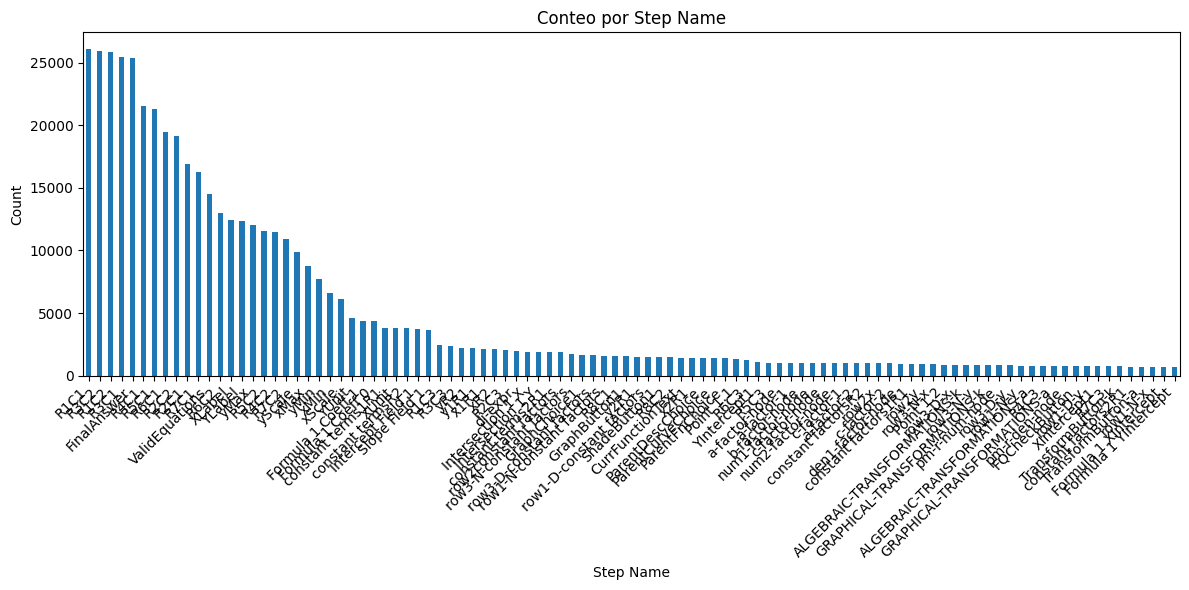

"\nplt.figure(figsize=(12, 6))\ngrouped_by_step_name.plot(kind='bar')\nplt.xlabel('Step Name')\nplt.ylabel('Number of Occurrences')\nplt.title('Distribution of Step Names')\nplt.xticks(rotation=45)\nplt.tight_layout()\nplt.show()\nprint(grouped_by_step_name)\n"

In [84]:
print("Unique Step Names:", traindata['Step Name'].unique())
unique_step_names = traindata['Step Name'].unique()
print("Number of unique Step Names:", len(unique_step_names))
counts=(
    traindata.groupby('Step Name')
    .size().sort_values(ascending=False)
    .reset_index(name='count')
)
print(counts.head(1000))

counts.to_csv(DATA_RAW / 'step_name_counts.csv', index=False, encoding='utf-8')


ax=counts.head(100).plot(kind='bar',x="Step Name",y="count", legend=False, figsize=(12,6))
ax.set_title("Conteo por Step Name")
ax.set_xlabel("Step Name")
ax.set_ylabel("Count")
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()

#grouped_by_step_name = traindata.groupby('Step Name').size()
#grouped_by_step_name.sort_values(ascending=False, inplace=True)
#grouped_by_step_name.head(1000)
"""
plt.figure(figsize=(12, 6))
grouped_by_step_name.plot(kind='bar')
plt.xlabel('Step Name')
plt.ylabel('Number of Occurrences')
plt.title('Distribution of Step Names')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print(grouped_by_step_name)
"""



In [85]:
traindata['Anon Student Id']

0         0BrbPbwCMz
1         0BrbPbwCMz
2         0BrbPbwCMz
3         0BrbPbwCMz
4         0BrbPbwCMz
             ...    
813656    pVG9cgOpCR
813657    w0FMzJORlK
813658    1iPV6aca5w
813659    66l1WHbu0M
813660    IQQo3367x0
Name: Anon Student Id, Length: 813661, dtype: object

['0BrbPbwCMz' '19UbXBlPPK' '2oNLCndtam' '46z59pQP58' '52vEY7f17k'
 '5ey2xUDZTA' '6W08a98ZQV' '8o0mJnIpFH' '8rsfNQdio8' '9hs21hUG5O'
 'b2W4ZO3uLV' 'g209g5Vve6' 'iyLqACAFyl' 'l8kuAhlIWI' 'QER9PsCgBT'
 'Ugr5eIIEf0' 'XqBaV46VbC' 'y8BlGe62E7' 'yDO9pl8GC0' '0jSb6S70X1'
 '1to8tgu4IT' '5LMy832c47' '668lBbaKFE' '6Ax4SKe470' '6O31vedZbI'
 '7oiAa7MlW2' '879eYkR2Wu' '8ZPoEJbXB7' '9493h91NUB' 'AQfVkV1aEx'
 'C18qWKq212' 'F25axtfCKG' 'PpTLi2Qz8E' 'tB4vqSxzqo' 'XNEgfvXx50'
 '0w3IAZa8rQ' '3hSu07XfGd' '6bJ4auIa8L' 'CaA0123UJL' 'ey9rvMnU57'
 'M7hLaVJGvX' 'mNzo8mGzu9' 'z9svx3mA4s' '34f4oB5Cod' '39Uc7ru04l'
 '589M2uPIY4' '6dGeA2ZpO4' '77y7iIIXuv' '7RB2G4NbCn' '9eV0EGVC6j'
 'c1zVCHxCEz' 'f4fNYL73Z2' 'Fx8d98DRud' 'jR1rpwLHNu' 'LM96hW22T2'
 'oEt3YTvS4G' 'q9Pk62y29S' 't0fI2c7EMH' 'XJyS25Yg27' 'jbw83hRJZQ'
 '13yR9KFHCI' '1z5YH40155' '23T7Up1oQ6' 'LIXD5c0lE5' 'olyVui8lHe'
 'SKThcG9N8q' 'VgP99sQ5jS' 'xa6ovLs5IM' '075kbY53c1' '5cuKF3lL4D'
 '8eqtD31y66' '938jD6Z338' 'c3Ee3W8hyq' 'c8Gl35DPn4' 'EV28POlwE4'
 'h0UbH181

Text(0, 0.5, 'Count')

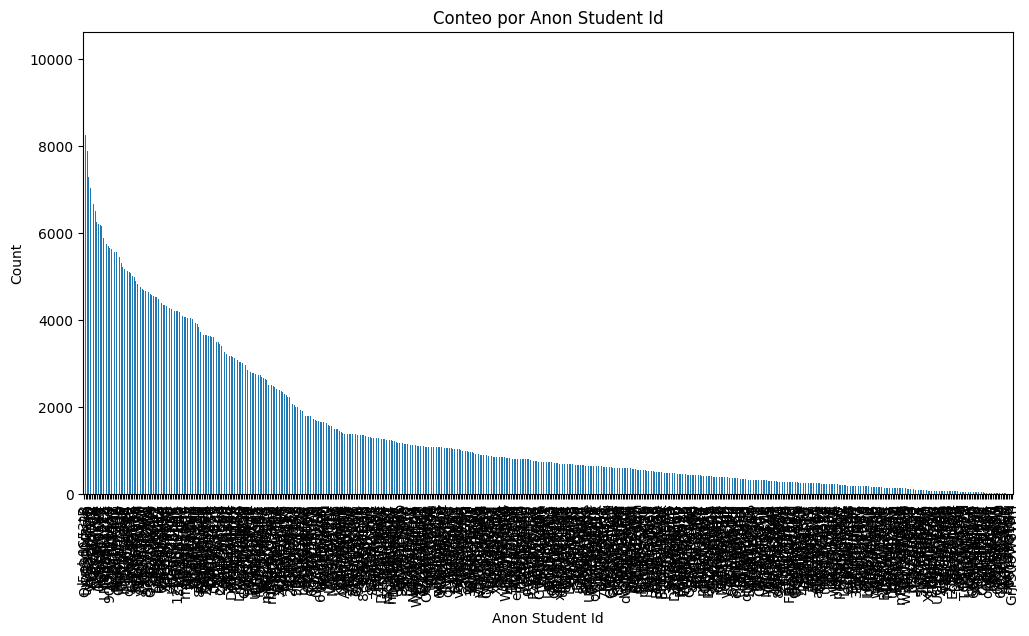

In [86]:
print(traindata['Anon Student Id'].unique())
print("Number of unique Anon Student Ids:", traindata['Anon Student Id'].nunique())

counts_students=(traindata
                 .groupby('Anon Student Id')
                 .size()
                 .sort_values(ascending=False)
                 .reset_index(name='count')
                 )

print(counts_students.head(1000))

counts_students.to_csv(DATA_RAW/ 'student_id_counts.csv', index=False,encoding='utf-8')

#grafica
ax=counts_students.head(1000).plot(kind='bar',x="Anon Student Id", y="count", legend=False, figsize=(12,6))
ax.set_title("Conteo por Anon Student Id")
ax.set_xlabel("Anon Student Id")
ax.set_ylabel("Count")
#ax.set_xaxis(False)  # Oculta los ejes para mejorar la legibilidad
#plt.xticks(rotation=45, ha='right')

[  2.   0.   1.   3.   4.   6.  12.  14.   5.   9.   8.   7.  10.  15.
  16.  25.  24.  20.  13.  11.  37.  18.  40.  39.  28.  21.  94.  31.
  45.  17.  22.  30.  26.  92.  65.  38.  23.  19.  34. 308.  29.  32.
  35.  54.  48.  57.  79.  27.  61. 126.  47.  51.  46.  64.  43.  60.
 114.  36.  50.  42.  33. 333.  67.  96.  81.  73.  88.  80.  52. 118.
  44.  55. 144.  59.  83.  49.  41.  91.  58.  74. 163.  85.  53.  56.
  78.  82. 100. 105.  77.  75. 149. 139. 115.  86. 109. 166.  68.  87.
  66.  63. 102. 106.  71. 161. 228. 122. 207. 112. 175.  69.  nan]
Number of unique Incorrects values: 110
     Incorrects   count
0           0.0  636201
1           1.0   97073
2           2.0   33411
3           3.0   17492
4           4.0    8719
..          ...     ...
105        80.0       1
106        78.0       1
107        74.0       1
108        66.0       1
109       333.0       1

[110 rows x 2 columns]


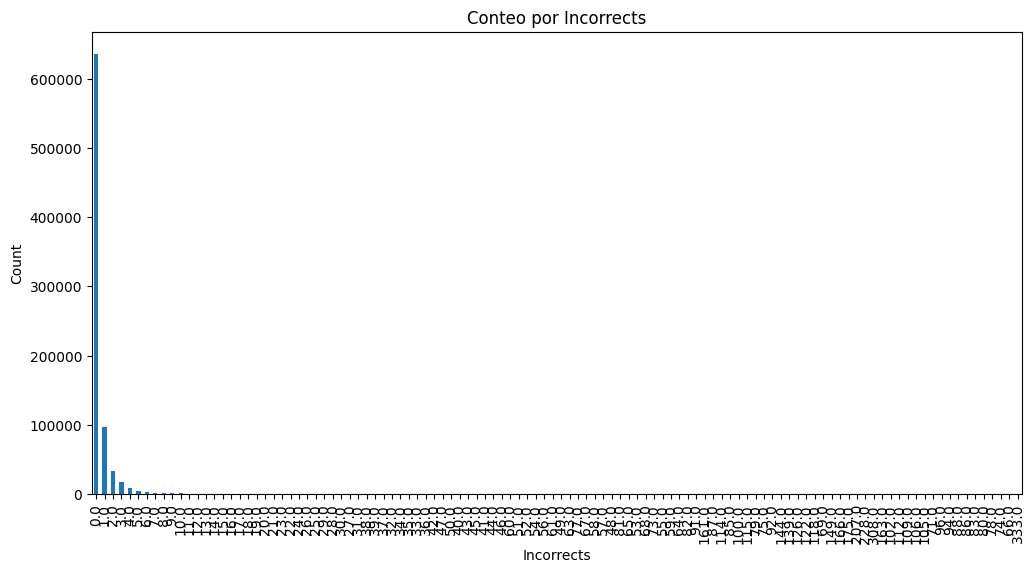

In [87]:
traindata['Incorrects']
print(traindata['Incorrects'].unique())
print("Number of unique Incorrects values:", traindata['Incorrects'].nunique())
counts_incorrects=(traindata.groupby('Incorrects')
                 .size()
                 .sort_values(ascending=False)
                 .reset_index(name='count' )
)

print(counts_incorrects.head(1000))

ax=counts_incorrects.plot(kind='bar',x="Incorrects", y="count",legend=False,figsize=(12,6))
ax.set_title("Conteo por Incorrects")
ax.set_xlabel("Incorrects")
ax.set_ylabel("Count")

counts_incorrects.to_csv(DATA_RAW / 'incorrects_counts.csv', index=False, encoding='utf-8')




## para ver autloierar los datos, se puede usar la libreria autloier, que es una libreria de python para detectar outliers en los datos. Se puede usar para detectar outliers en la columna 'Incorrects' y en la columna 'Anon Student Id'.


Outliers in Incorrects:
count    809694.000000
mean          0.504276
std           2.036774
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
95%           3.000000
99%           7.000000
max         333.000000
Name: Incorrects, dtype: float64


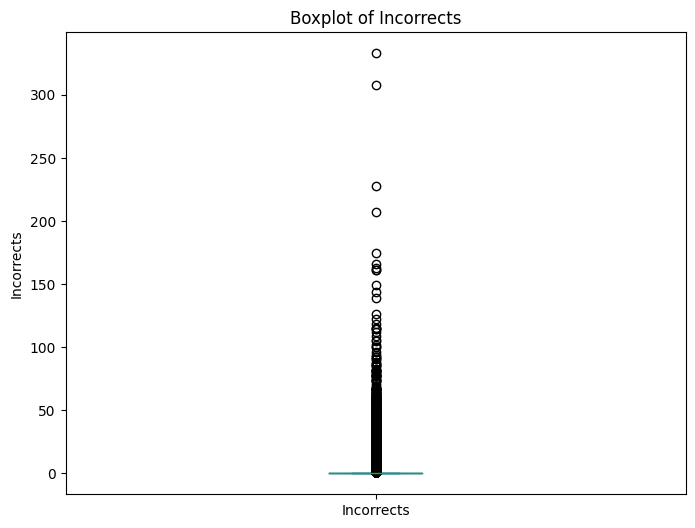

In [88]:
outliers_incorrects = traindata['Incorrects'].astype(float)
print("Outliers in Incorrects:")
print(outliers_incorrects.describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]))

ax_outliers = outliers_incorrects.plot(kind="box", figsize=(8, 6))
ax_outliers.set_title("Boxplot of Incorrects")
ax_outliers.set_ylabel("Incorrects")
plt.show()

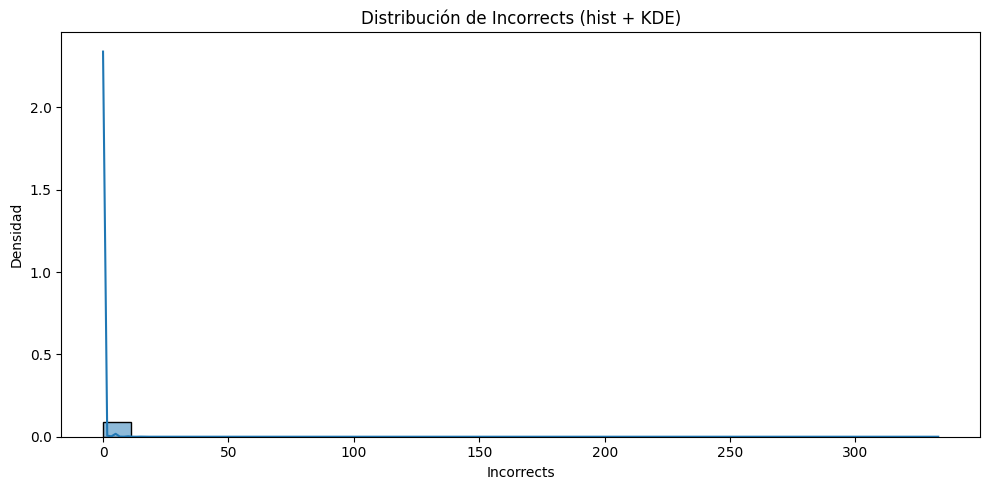

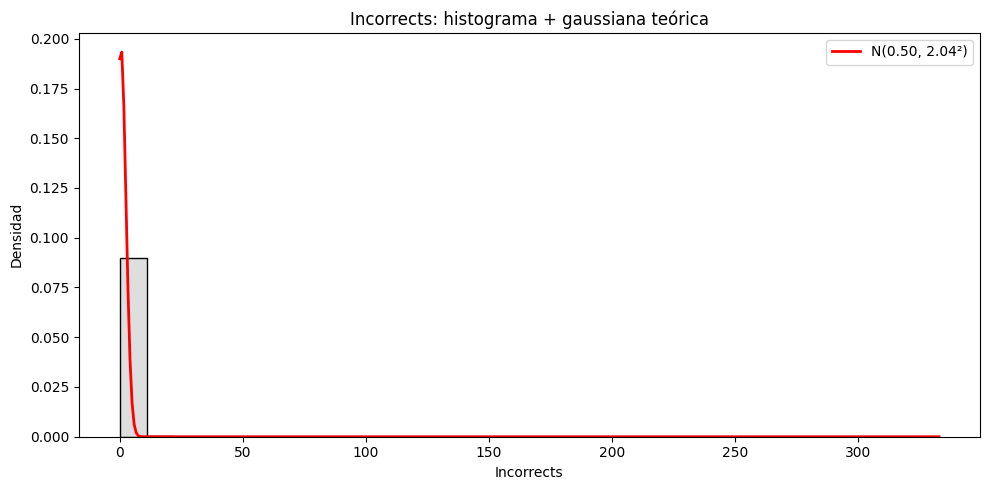

In [89]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

s = traindata["Incorrects"].astype(float).dropna()

# Histograma + "campana" (KDE)
plt.figure(figsize=(10,5))
sns.histplot(s, bins=30, stat="density", kde=True)
plt.title("Distribución de Incorrects (hist + KDE)")
plt.xlabel("Incorrects")
plt.ylabel("Densidad")
plt.tight_layout()
plt.show()

# Gaussiana teórica con misma media y desviación
mu, sigma = s.mean(), s.std(ddof=1)
x = np.linspace(s.min(), s.max(), 400)
pdf = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mu)/sigma)**2)

plt.figure(figsize=(10,5))
sns.histplot(s, bins=30, stat="density", color="lightgray")
plt.plot(x, pdf, color="red", linewidth=2, label=f"N({mu:.2f}, {sigma:.2f}²)")
plt.title("Incorrects: histograma + gaussiana teórica")
plt.xlabel("Incorrects")
plt.ylabel("Densidad")
plt.legend()
plt.tight_layout()
plt.show()


[  3.   0.   2.   1.   4.   5.   7.   6.  12.   8.  10.  70.  16.   9.
  39.  14.  11.  19.  17.  15.  18.  13.  30.  21.  36.  29.  27.  23.
  32.  28.  31.  43.  22.  20.  42.  25.  40.  26.  60.  77.  24.  46.
 217.  51.  52.  57.  33.  50.  37.  45.  38.  72.  35.  44.  74.  85.
  34.  78.  56.  62.  nan]
Number of unique Hints values: 60
    Hints   count
0     0.0  731081
1     2.0   21452
2     3.0   18015
3     1.0   15667
4     4.0    9346
5     5.0    7722
6     6.0    2754
7     7.0     954
8     8.0     724
9     9.0     458
10   10.0     327
11   11.0     237
12   12.0     206
13   13.0     123
14   14.0     116
15   15.0      85
16   16.0      65
17   17.0      51
18   19.0      42
19   21.0      39
20   18.0      36
21   20.0      20
22   22.0      18
23   28.0      17
24   23.0      17
25   24.0      13
26   27.0      13
27   25.0      10
28   26.0       9
29   32.0       8
30   33.0       8
31   29.0       7
32   31.0       5
33   36.0       4
34   39.0       4
35   30

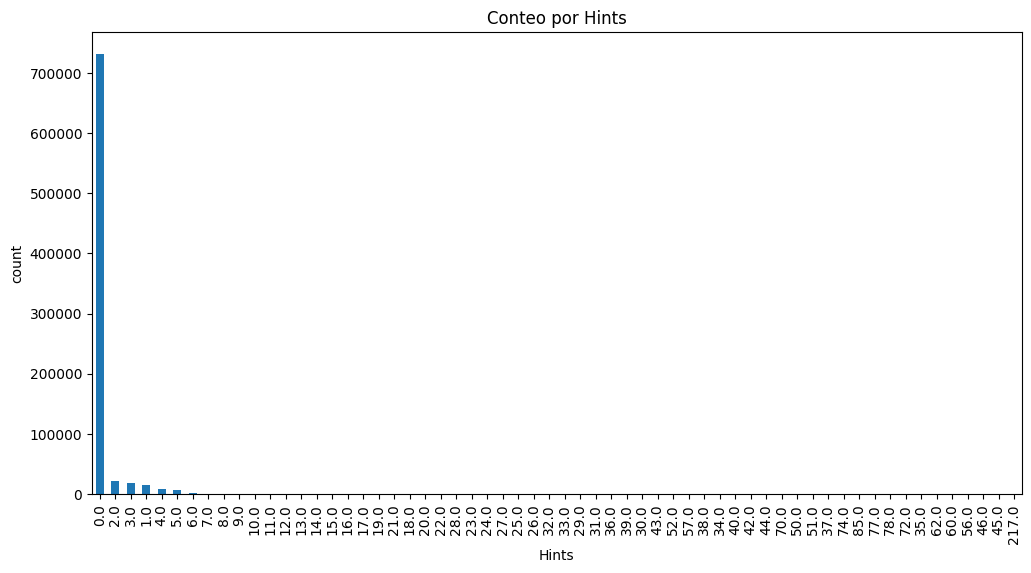

In [90]:
#hints
print(traindata['Hints'].unique())
print("Number of unique Hints values:", traindata['Hints'].nunique())

counts_hints= (traindata.groupby('Hints')
               .size()
               .sort_values(ascending=False)
               .reset_index(name='count')
               )
ax=counts_hints.plot(kind='bar', x="Hints", y="count", legend=False, figsize=(12,6))
ax.set_title("Conteo por Hints")
ax.set_xlabel("Hints")
ax.set_ylabel("count")

print(counts_hints.head(1000))

counts_hints.to_csv(DATA_RAW / "hints_counts.csv", index=False, encoding='utf-8')


Outliers in Hints:
count    809694.000000
mean          0.302483
std           1.242620
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
95%           3.000000
99%           5.000000
max         217.000000
Name: Hints, dtype: float64


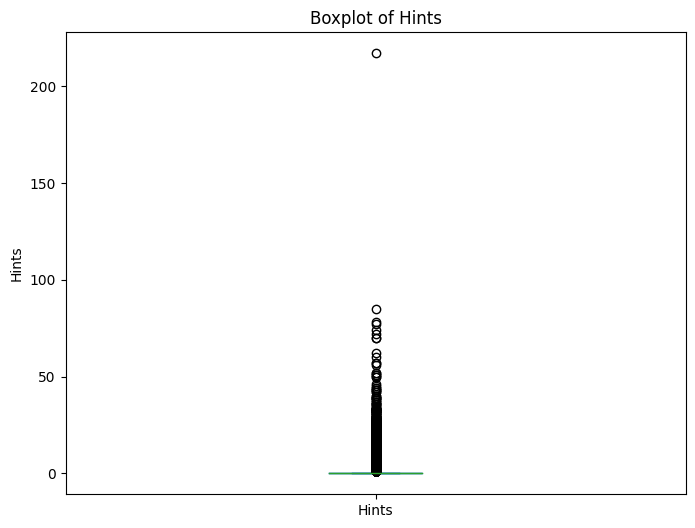

In [91]:


outliers_hints = traindata['Hints'].astype(float)
print("Outliers in Hints:")
print(outliers_hints.describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]))

ax_outliers_hints = outliers_hints.plot(kind="box", figsize=(8, 6))
ax_outliers_hints.set_title("Boxplot of Hints")
ax_outliers_hints.set_ylabel("Hints")
plt.show()


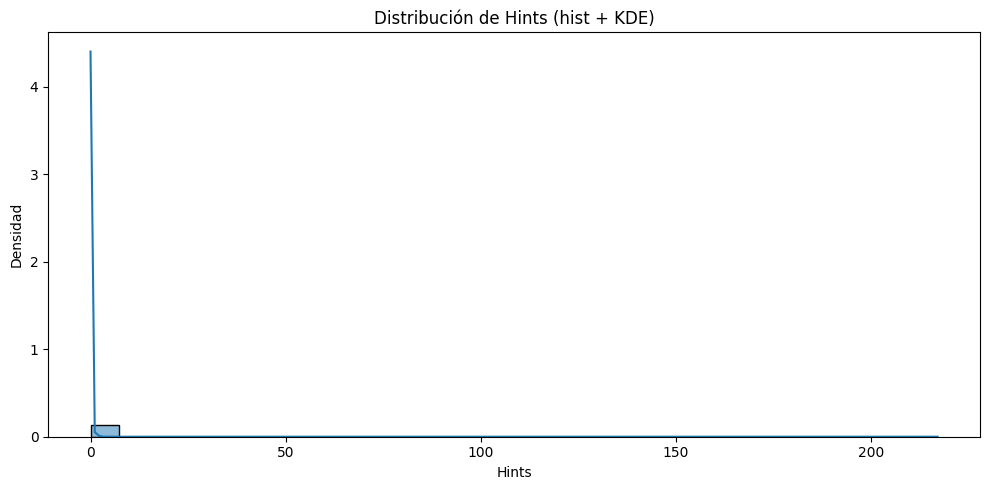

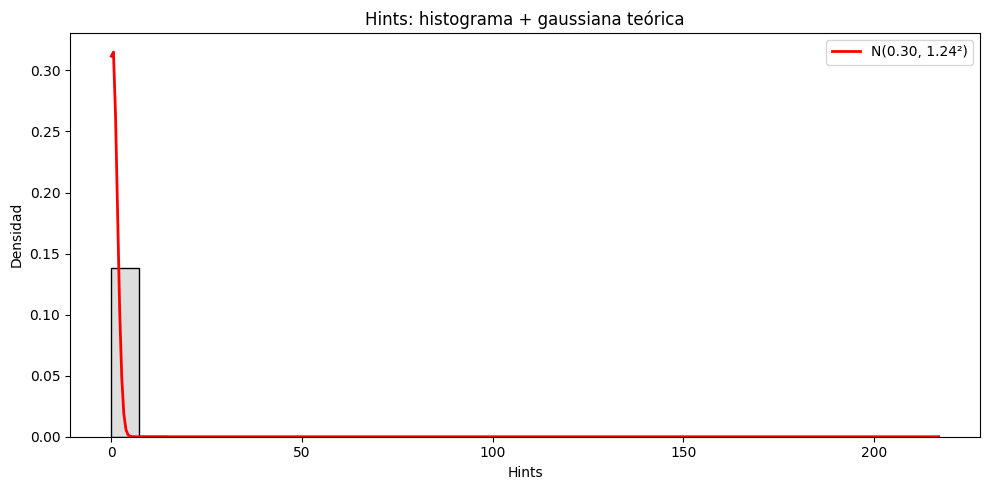

In [92]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

s = traindata["Hints"].astype(float).dropna()

# Histograma + campana (KDE)
plt.figure(figsize=(10,5))
sns.histplot(s, bins=30, stat="density", kde=True)
plt.title("Distribución de Hints (hist + KDE)")
plt.xlabel("Hints")
plt.ylabel("Densidad")
plt.tight_layout()
plt.show()

# Gaussiana teórica con misma media y desviación
mu, sigma = s.mean(), s.std(ddof=1)
x = np.linspace(s.min(), s.max(), 400)
pdf = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mu)/sigma)**2)

plt.figure(figsize=(10,5))
sns.histplot(s, bins=30, stat="density", color="lightgray")
plt.plot(x, pdf, color="red", linewidth=2, label=f"N({mu:.2f}, {sigma:.2f}²)")
plt.title("Hints: histograma + gaussiana teórica")
plt.xlabel("Hints")
plt.ylabel("Densidad")
plt.legend()
plt.tight_layout()
plt.show()


[ 0.  1. nan]
Number of unique Correct First Attempt values: 2


Text(0, 0.5, 'count')

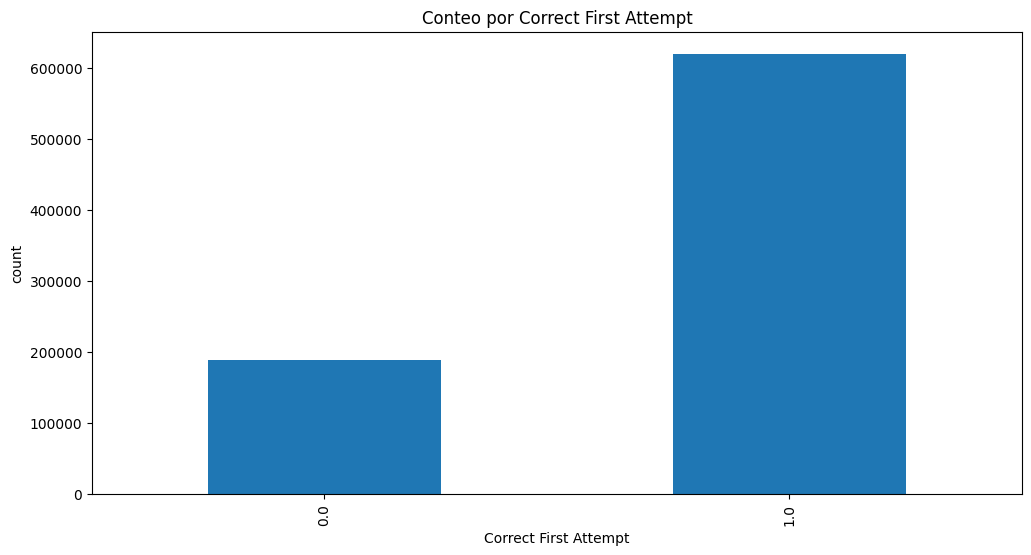

In [93]:
#correct_first_attempt
#Correct First Attempt
print(traindata['Correct First Attempt'].unique())
print("Number of unique Correct First Attempt values:", traindata['Correct First Attempt'].nunique())

counts_correct_first_attempt = (traindata.groupby('Correct First Attempt')
                              .size()
                              .reset_index(name='count')
                              )
counts_correct_first_attempt.to_csv(DATA_RAW / "correct_first_attempt_counts.csv", index=False, encoding='utf-8')

ax=counts_correct_first_attempt.plot(kind='bar', x="Correct First Attempt", y="count", legend=False, figsize=(12,6))
ax.set_title("Conteo por Correct First Attempt")
ax.set_xlabel("Correct First Attempt")
ax.set_ylabel("count")


[ 40.     16.     36.    ... 195.001 244.996 122.002]
Number of unique step_duration_sec values: 3056
     Step Duration (sec)  count
0                  4.000  54365
1                  5.000  54118
2                  6.000  48844
3                  3.000  48648
4                  7.000  42441
..                   ...    ...
995              148.999      3
996              137.999      3
997              149.995      3
998              149.500      3
999              132.001      3

[1000 rows x 2 columns]


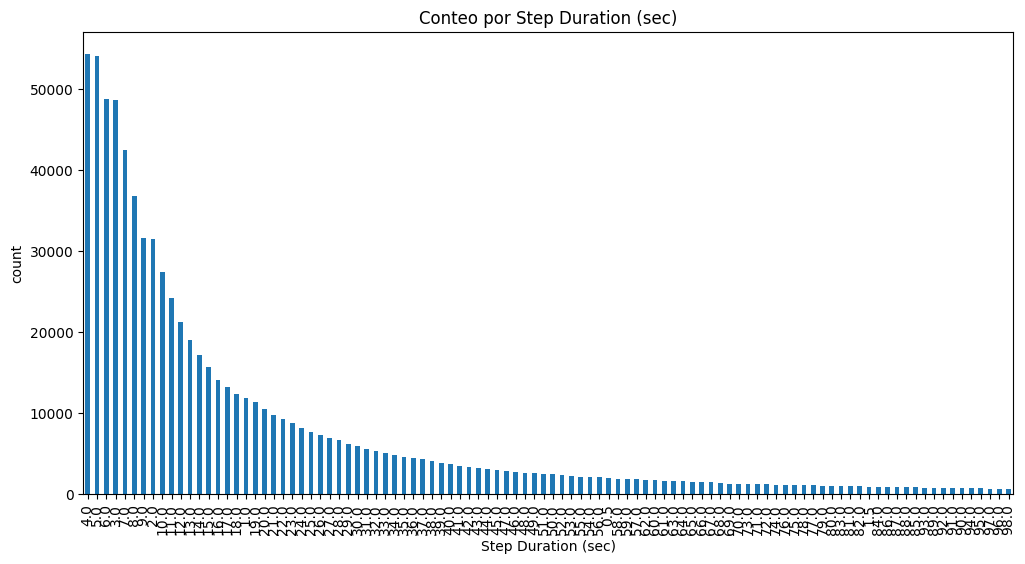

In [94]:
#step_duration_sec
print(traindata['Step Duration (sec)'].unique())
print("Number of unique step_duration_sec values:", traindata['Step Duration (sec)'].nunique())

counts_step_duration_sec = (traindata.groupby('Step Duration (sec)')
                           .size()
                            .sort_values(ascending=False)
                            .reset_index(name='count')
                            )
print(counts_step_duration_sec.head(1000))

ax=counts_step_duration_sec.head(100).plot(kind='bar',x="Step Duration (sec)",y="count", legend=False, figsize=(12,6))
ax.set_title("Conteo por Step Duration (sec)")  
ax.set_xlabel("Step Duration (sec)")
ax.set_ylabel("count")
counts_step_duration_sec.to_csv(DATA_RAW / "step_duration_sec_counts.csv", index=False, encoding='utf-8')


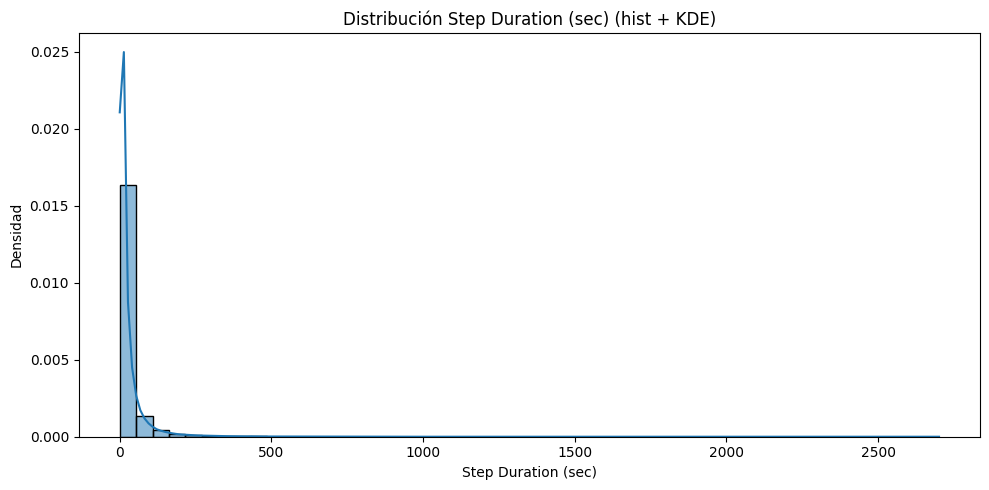

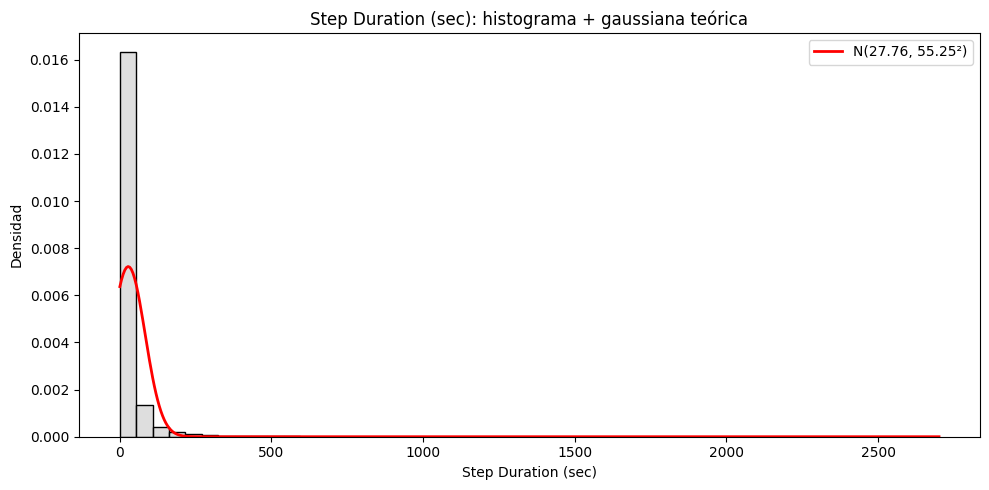

In [95]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

s = traindata["Step Duration (sec)"].astype(float).dropna()

# (Opcional) filtra ceros/negativos si existen
s = s[s > 0]

# Histograma + campana (KDE)
plt.figure(figsize=(10,5))
sns.histplot(s, bins=50, stat="density", kde=True)
plt.title("Distribución Step Duration (sec) (hist + KDE)")
plt.xlabel("Step Duration (sec)")
plt.ylabel("Densidad")
plt.tight_layout()
plt.show()

# Gaussiana teórica con misma media y desviación
mu, sigma = s.mean(), s.std(ddof=1)
x = np.linspace(s.min(), s.max(), 500)
pdf = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mu)/sigma)**2)

plt.figure(figsize=(10,5))
sns.histplot(s, bins=50, stat="density", color="lightgray")
plt.plot(x, pdf, "r", lw=2, label=f"N({mu:.2f}, {sigma:.2f}²)")
plt.title("Step Duration (sec): histograma + gaussiana teórica")
plt.xlabel("Step Duration (sec)")
plt.ylabel("Densidad")
plt.legend()
plt.tight_layout()
plt.show()


count    808775.000000
mean         27.744935
std          55.246830
min           0.000000
50%          11.000000
75%          27.000000
90%          62.000000
95%         104.000000
99%         270.000000
99.9%       601.000000
max        2701.000000
Name: Step Duration (sec), dtype: float64


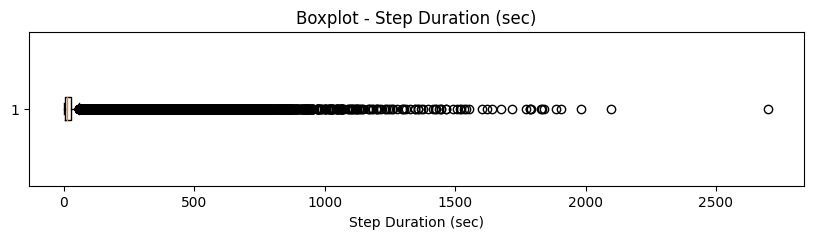

IQR bounds: -28.0 60.0
Outlier rows: 84218
count    84218.000000
mean       141.503244
std        115.582572
min         60.001000
25%         76.000000
50%        101.000000
75%        158.000000
max       2701.000000
Name: Step Duration (sec), dtype: float64
676402    2701.000
677654    2096.000
754635    1981.000
240674    1907.000
173223    1888.000
442715    1842.000
719758    1834.000
778758    1831.000
19342     1791.000
50102     1787.000
301877    1785.667
634962    1771.000
754141    1717.000
277340    1676.000
708912    1641.000
151566    1622.000
227871    1605.000
351692    1554.000
668661    1542.000
551330    1533.000
Name: Step Duration (sec), dtype: float64


In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

s = traindata["Step Duration (sec)"].astype(float)

# opcional: descarta negativos
s = s.where(s >= 0)

# 1) resumen con percentiles (cola)
print(s.dropna().describe(percentiles=[.5, .75, .9, .95, .99, .999]))

# 2) boxplot (visual)
plt.figure(figsize=(10,2))
plt.boxplot(s.dropna(), vert=False, showfliers=True)
plt.title("Boxplot - Step Duration (sec)")
plt.xlabel("Step Duration (sec)")
plt.show()

# 3) outliers por IQR
q1, q3 = s.quantile([0.25, 0.75])
iqr = q3 - q1
low = q1 - 1.5 * iqr
high = q3 + 1.5 * iqr

out = traindata[(traindata["Step Duration (sec)"] < low) | (traindata["Step Duration (sec)"] > high)]
print("IQR bounds:", low, high)
print("Outlier rows:", len(out))
print(out["Step Duration (sec)"].describe())
print(out["Step Duration (sec)"].sort_values(ascending=False).head(20))


In [99]:
#LIMPIEZA DE DATA
step_name_to_delete = ["R1C1",
"R3C2",
"R1C2",
"R3C1",
"FinalAnswer",
"R4C1",
"R5C1",
"R6C1",
"R2C2",
"R2C1",
"R7C1",
"ValidEquations",
"R6C2",
"XLabel",
"YLabel",
"yMax",
"R5C2",
"R4C2",
"R7C2",
"yScale",
"xMax",
"yMin",
"xMin",
"xScale",
"YUnit",
"Formula 1 Coeff 1",
"Formula 1 Coeff 0",
"constant terms1R1",
"XUnit",
"constant termsR2",
"Intercept Field 1",
"Slope Field 1",
"R1C3",
"R3C3",
"yR2",
"y1R1",
"x1R1",
"xR2",
"R2C3",
"di-expr",
"Intersection 1 X",
"Intersection 1 Y",
"constant terms2R1",
"row2constant factors",
"row3-N-constant factors",
"GraphChoice1",
"row3-D-constant factors",
"row1-N-constant factors",
"R8C1",
"GraphButton1",
"y2R1",
"row1-D-constant factors",
"ShadeButton1",
"R8C2",
"CurrFunctionText",
"x2R1",
"ParentDescChoice",
"ParentCurveChoice",
"ParentFnChoice",
"Point 1.1",
"R6C3",
"YIntercept1",
"R5C3",
"a-factor-node",
"a-factor-1",
"b-factor-node",
"num1-factor-node",
"c-factor-node",
"num2-factor-node",
"c-factor-1",
"a-factor-2",
"constant factorsR2",
"row2x",
"c-factor-2",
"den1-factor-node",
"constant factors1R1",
"row2y",
"row3-N-x",
"Point 1.2",
"row3-D-x",
"ALGEBRAIC-TRANSFORMATIONS-k",
"row3-N-y",
"GRAPHICAL-TRANSFORMATIONS-k",
"pm-r-num-node",
"row3-D-y",
"row1-N-y",
"ALGEBRAIC-TRANSFORMATIONS-a",
"R4C3",
"GRAPHICAL-TRANSFORMATIONS-a",
"pm-r-den-node",
"FQCheckButton",
"row1-D-y",
"XIntercept1",
"R7C3",
"TransformButton-k",
"constant factors2R1",
"TransformButton-a",
"row1-N-x",
"Formula 1 XIntercept",
"Formula 1 YIntercept",
"Point 1.3",
"YCoordinate1_1",
"GRAPHICAL-TRANSFORMATIONS-refl-v",
"Point 1.4",
"XCoordinate1_1",
"row1-D-x",
"XCoordinate1_2",
"YCoordinate1_2",
"Formula 1 Point 1",
"ALGEBRAIC-TRANSFORMATIONS-refl-v",
"Formula 1 Point 2",
"GRAPHICAL-TRANSFORMATIONS-h",
"FQTryAgainButton",
"R9C2",
"ALGEBRAIC-TRANSFORMATIONS-h",
"TransformButton-refl-v",
"Slope1",
"R9C1",
"TransformButton-h",
"Add Point",
"R8C3",
"R10C2",
"R10C1",
"ALGEBRAIC-TRANSFORMATIONS",
"INNERr1",
"INNERr2",
"INNERn1",
"INNERn2",
"INNERx1",
"INNERx2",
"Point 1.5",
"INNERq2",
"INNERq1",
"INNERg1",
"INNERg2",
"R9C3",
"INNERw2",
"INNERw1",
"INNERu1",
"INNERu2",
"INNERv2",
"INNERv1",
"INNERj1",
"INNERj2",
"INNERm1",
"INNERm2",
"Formula 1 Label",
"R11C2",
"INNERk2",
"INNERk1",
"R11C1",
"Y1R1",
"INNERz2",
"INNERz1"]

print("Step Names to delete:", step_name_to_delete)
print("Number of Step Names to delete:", len(step_name_to_delete))

Step Names to delete: ['R1C1', 'R3C2', 'R1C2', 'R3C1', 'FinalAnswer', 'R4C1', 'R5C1', 'R6C1', 'R2C2', 'R2C1', 'R7C1', 'ValidEquations', 'R6C2', 'XLabel', 'YLabel', 'yMax', 'R5C2', 'R4C2', 'R7C2', 'yScale', 'xMax', 'yMin', 'xMin', 'xScale', 'YUnit', 'Formula 1 Coeff 1', 'Formula 1 Coeff 0', 'constant terms1R1', 'XUnit', 'constant termsR2', 'Intercept Field 1', 'Slope Field 1', 'R1C3', 'R3C3', 'yR2', 'y1R1', 'x1R1', 'xR2', 'R2C3', 'di-expr', 'Intersection 1 X', 'Intersection 1 Y', 'constant terms2R1', 'row2constant factors', 'row3-N-constant factors', 'GraphChoice1', 'row3-D-constant factors', 'row1-N-constant factors', 'R8C1', 'GraphButton1', 'y2R1', 'row1-D-constant factors', 'ShadeButton1', 'R8C2', 'CurrFunctionText', 'x2R1', 'ParentDescChoice', 'ParentCurveChoice', 'ParentFnChoice', 'Point 1.1', 'R6C3', 'YIntercept1', 'R5C3', 'a-factor-node', 'a-factor-1', 'b-factor-node', 'num1-factor-node', 'c-factor-node', 'num2-factor-node', 'c-factor-1', 'a-factor-2', 'constant factorsR2', 'row2

In [100]:
traindata_cleaned = traindata[~traindata['Step Name'].isin(step_name_to_delete)]
print("Shape of cleaned data:", traindata_cleaned.shape)
print("Number of rows in cleaned data:", traindata_cleaned.shape[0])

Shape of cleaned data: (300998, 19)
Number of rows in cleaned data: 300998


(187984, 2)


Text(0, 0.5, 'Count')

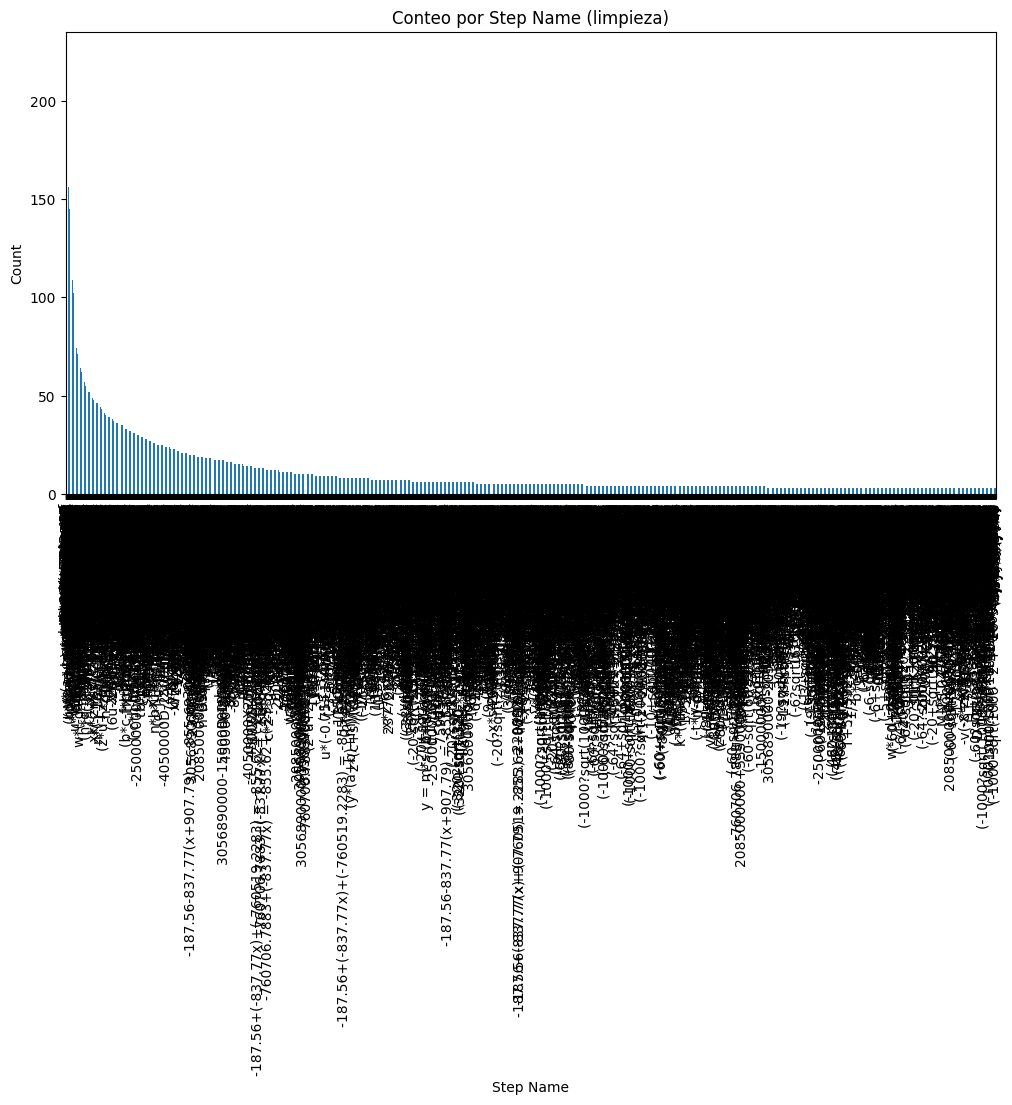

In [107]:
counts_cleaned_step_names = (traindata_cleaned.groupby('Step Name')
                            .size()
                            .sort_values(ascending=False)
                            .reset_index(name='count'))
print(counts_cleaned_step_names.shape)

ax=counts_cleaned_step_names.head(10000).plot(kind='bar',x="Step Name",y="count", legend=False, figsize=(12,6))
ax.set_title("Conteo por Step Name (limpieza)")
ax.set_xlabel("Step Name")
ax.set_ylabel("Count")


In [109]:
#Incorrectos
col = "Incorrects"

p = 0.99  # 0.99 o 0.995
thr = traindata_cleaned[col].quantile(p)

traindata_f = traindata_cleaned[traindata_cleaned[col] <= thr].copy()

print("umbral:", thr)
print("filas antes:", len(traindata_cleaned), "después:", len(traindata_f))


umbral: 5.0
filas antes: 300998 después: 297704


Let's begin asking some basic questions of the data

### How many students are interacting with the system?

In [ ]:
# Take the column of anonimized student IDs and count the number of unique entries
print('Number of students: ', len(np.unique(traindata['Anon Student Id'])))



Number of students:  574


### How long does it take a student to solve any problem step on average?

In [14]:
csd = traindata['Correct Step Duration (sec)']
csd.describe()

count    620129.000000
mean         18.071478
std          34.796694
min           0.000000
25%           5.000000
50%           8.000000
75%          18.000000
max        1907.000000
Name: Correct Step Duration (sec), dtype: float64

So ignoring all the students that did not solve a problem step correctly, the average duraction for any problem step was about 18 seconds.

Let's histogram this data to see the distribution.

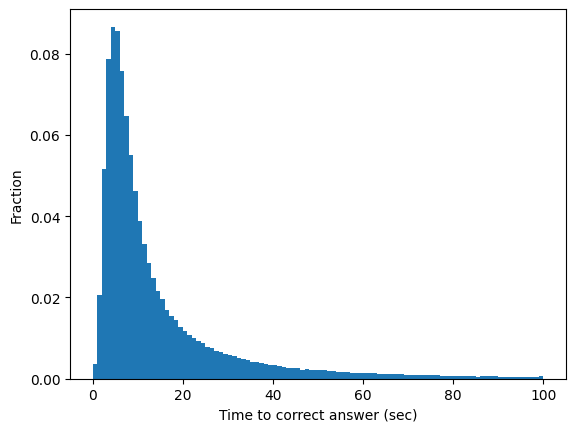

In [16]:
%matplotlib inline
hist = plt.hist(np.array(csd.dropna()),bins=100,density=True,log=False,range=(0,100))
plt.xlabel('Time to correct answer (sec)')
plt.ylabel('Fraction')
plt.show()

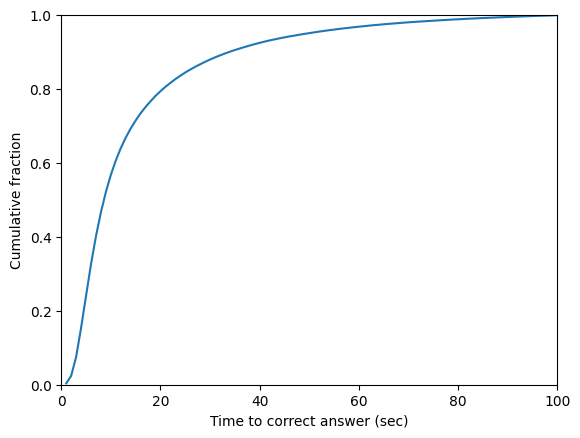

In [17]:
counts, bins = hist[0], hist[1]
cdf = np.cumsum(counts)
plt.plot(bins[1::], cdf)
plt.xlabel('Time to correct answer (sec)')
plt.ylabel('Cumulative fraction')
plt.axis((0,100,0,1.0))
plt.show()

The histogram shows visually what mere statistics hints at. The distribution of students is heavily weighted towards those who are solving problems in under 20 seconds. The cumulative distribution function (CDF) shows that roughly 80% of successful students solve the problem within 20 seconds. After 40 seconds, 90% of successful students have finished the problem. Almost no students take longer than 80 seconds.

### Completion time by problem

OK, let's ask a slightly harder question: how are students doing problem by problem? The answer will take several parts.

First, let's get the number of unique problems

In [20]:
# The unique identifier for each problem is the 'Problem Name'
problems = traindata['Problem Name']

In [21]:
# Get just the uniques
problems = np.unique(problems)
print('Number of unique problems: ', len(problems))

Number of unique problems:  1084


Then, let's compute which problems need the largest time on average.

In [22]:
pmedian_times = {}
for p in problems:
    pmedian_times[p] = traindata[traindata['Problem Name'] == p]['Correct Step Duration (sec)'].median()

c:\Users\javie\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\javie\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\javie\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\javie\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\javie\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [64]:
import operator

In [65]:
sorted_times = sorted(pmedian_times.items(), key=operator.itemgetter(1), reverse=True)

In [66]:
print("The hardest top-5 problem and its average correct duration (sec).")
print(sorted_times[:5])

print("The earliest top-5 problem and its average correct duration (sec).")
print(sorted_times[len(sorted_times)-5:])

The hardest top-5 problem and its average correct duration (sec).
[('JAN13C', 65.0), ('TRANSFORMN022', 32.0), ('EG-FACTOR45', 30.0), ('JAN13A', 25.5), ('LIT76A', 23.5)]
The earliest top-5 problem and its average correct duration (sec).
[('TRANSFORMG038', 1.5), ('TRANSFORMA045', 1.5), ('TRANSFORMA035', 1.25), ('TRANSFORMG039', 1.25), ('TRANSFORMN005', 1.0)]


Statistical results of problem difficulty

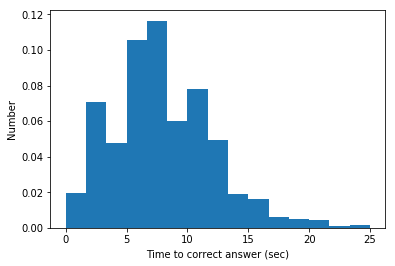

In [67]:
hist = plt.hist(np.array(list(pmedian_times.values())),bins=15,density=True,log=False,range=(0,25))
plt.xlabel('Time to correct answer (sec)')
plt.ylabel('Number')
plt.show()

If we take the time to correct answer as the difficulty of a problem, the histogram shows visually the difficulties of all the problems. 

### Conclusion
There are many other interesting characteristic in this dataset.
Like, 
* After some practices, students may become better at solving problems.
* Same problem step for different students may request different knowledge components. Or for some problems, there is only one correct knowledge components

These may be some things you need to take consider into for the feature engineering part. We leave them for you to explore deeper.

# Part 0: Initialize

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import random
pd.options.display.max_columns = None
pd.options.display.max_rows = 1000
from sklearn.model_selection import cross_val_score

In [2]:
traindata_origin = pd.read_csv('data/train.csv',sep = '\t')
testdata_origin = pd.read_csv('data/test.csv',sep = '\t')

# Part 1: Preprocess Data
## 1.1 Split Problem hierarchy
First, we should split 2 columns and remove the origin one.

#### Train Data

In [3]:
#temp_df = traindata_origin['Problem Hierarchy'].str.split(',')
temp_train = traindata_origin
temp_train['Problem Unit'] = traindata_origin['Problem Hierarchy'].str.split(',',1).str[0]
temp_train['Problem Section'] = traindata_origin['Problem Hierarchy'].str.split(',',1).str[1]

In [4]:
temp_train = temp_train.reindex(columns = ['Row','Anon Student Id','Problem Hierarchy','Problem Unit','Problem Section',\
                                    'Problem Name','Problem View','Step Name','Step Start Time',\
                                    'First Transaction Time','Correct Transaction Time',\
                                    'Step End Time','Step Duration (sec)','Correct Step Duration (sec)',\
                                    'Error Step Duration (sec)','Correct First Attempt','Incorrects',\
                                    'Hints','Corrects','KC(Default)','Opportunity(Default)'])

In [5]:
temp_train.head(1)

,Row,Anon Student Id,Problem Hierarchy,Problem Unit,Problem Section,Problem Name,Problem View,Step Name,Step Start Time,First Transaction Time,Correct Transaction Time,Step End Time,Step Duration (sec),Correct Step Duration (sec),Error Step Duration (sec),Correct First Attempt,Incorrects,Hints,Corrects,KC(Default),Opportunity(Default)
0,9938,52vEY7f17k,"Unit CTA1_13, Section CTA1_13-1",Unit CTA1_13,Section CTA1_13-1,PROP04,1,R1C1,2005-09-09 12:23:34.0,2005-09-09 12:24:07.0,2005-09-09 12:24:07.0,2005-09-09 12:24:07.0,33.0,33.0,NaN,1,0,0,1,NaN,NaN


In [6]:
traindata_pre = temp_train

#### Test Data

In [7]:
#temp_df = traindata_origin['Problem Hierarchy'].str.split(',')
temp_test = testdata_origin
temp_test['Problem Unit'] = testdata_origin['Problem Hierarchy'].str.split(',',1).str[0]
temp_test['Problem Section'] = testdata_origin['Problem Hierarchy'].str.split(',',1).str[1]

In [8]:
temp_test = temp_test.reindex(columns = ['Row','Anon Student Id','Problem Hierarchy','Problem Unit','Problem Section',\
                                    'Problem Name','Problem View','Step Name','Step Start Time',\
                                    'First Transaction Time','Correct Transaction Time',\
                                    'Step End Time','Step Duration (sec)','Correct Step Duration (sec)',\
                                    'Error Step Duration (sec)','Correct First Attempt','Incorrects',\
                                    'Hints','Corrects','KC(Default)','Opportunity(Default)'])

In [9]:
temp_test.head(1)

,Row,Anon Student Id,Problem Hierarchy,Problem Unit,Problem Section,Problem Name,Problem View,Step Name,Step Start Time,First Transaction Time,Correct Transaction Time,Step End Time,Step Duration (sec),Correct Step Duration (sec),Error Step Duration (sec),Correct First Attempt,Incorrects,Hints,Corrects,KC(Default),Opportunity(Default)
0,10039,52vEY7f17k,"Unit CTA1_13, Section CTA1_13-1",Unit CTA1_13,Section CTA1_13-1,PROP01,1,2/300*X = 10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
testdata_pre = temp_test

## 1.2 Map string to Integer

In [11]:
temp_train = traindata_pre

In [12]:
temp_test = testdata_pre

### 1. Anon Student Id

In [13]:
sids = list(set(temp_train['Anon Student Id']).union(set(temp_test['Anon Student Id'])))
sid_dict = {}
for index, sid in enumerate(sids):
    sid_dict[sid] = index
temp_train['Anon Student Id'] = temp_train['Anon Student Id'].apply(lambda x:sid_dict[x])
temp_test['Anon Student Id'] = temp_test['Anon Student Id'].apply(lambda x:sid_dict[x])
#     sid_dict[index] = sid
#     temp_train.loc[temp_train['Anon Student Id'] == sid, 'Anon Student Id'] = index
#     temp_test.loc[temp_test['Anon Student Id'] == sid, 'Anon Student Id'] = index

### 2. Problem Hierarchy

In [14]:
prohies = list(set(temp_train['Problem Hierarchy']).union(set(temp_test['Problem Hierarchy'])))
prohie_dict = {}
for index, prohie in enumerate(prohies):
    prohie_dict[prohie] = index
temp_train['Problem Hierarchy'] = temp_train['Problem Hierarchy'].apply(lambda x:prohie_dict[x])
temp_test['Problem Hierarchy'] = temp_test['Problem Hierarchy'].apply(lambda x:prohie_dict[x])
#     prohie_dict[index] = prohie
#     temp_train.loc[temp_train['Problem Hierarchy'] == prohie, 'Problem Hierarchy'] = index
#     temp_test.loc[temp_test['Problem Hierarchy'] == prohie, 'Problem Hierarchy'] = index

### 3. Problem Unit

In [15]:
prounis = list(set(temp_train['Problem Unit']).union(set(temp_test['Problem Unit'])))
prouni_dict = {}
for index, prouni in enumerate(prounis):
    prouni_dict[prouni] = index
temp_train['Problem Unit'] = temp_train['Problem Unit'].apply(lambda x:prouni_dict[x])
temp_test['Problem Unit'] = temp_test['Problem Unit'].apply(lambda x:prouni_dict[x])
#     prouni_dict[index] = prouni
#     temp_train.loc[temp_train['Problem Unit'] == prouni, 'Problem Unit'] = index
#     temp_test.loc[temp_test['Problem Unit'] == prouni, 'Problem Unit'] = index

### 4. Problem Section

In [16]:
prosecs = list(set(temp_train['Problem Section']).union(set(temp_test['Problem Section'])))
prosec_dict = {}
for index, prosec in enumerate(prosecs):
    prosec_dict[prosec] = index
temp_train['Problem Section'] = temp_train['Problem Section'].apply(lambda x:prosec_dict[x])
temp_test['Problem Section'] = temp_test['Problem Section'].apply(lambda x:prosec_dict[x])
#     prosec_dict[index] = prosec
#     temp_train.loc[temp_train['Problem Section'] == prosec, 'Problem Section'] = index
#     temp_test.loc[temp_test['Problem Section'] == prosec, 'Problem Section'] = index

### 5. Problem Name

In [17]:
pronams = list(set(temp_train['Problem Name']).union(set(temp_test['Problem Name'])))
pronam_dict = {}
for index,pronam in enumerate(pronams):
    pronam_dict[pronam] = index
temp_train['Problem Name'] = temp_train['Problem Name'].apply(lambda x:pronam_dict[x])
temp_test['Problem Name'] = temp_test['Problem Name'].apply(lambda x:pronam_dict[x])
#     pronam_dict[index] = pronam
#     temp_train.loc[temp_train['Problem Name'] == pronam, 'Problem Name'] = index
#     temp_test.loc[temp_test['Problem Name'] == pronam, 'Problem Name'] = index

### 6. Step Name

In [18]:
stenams = list(set(temp_train['Step Name']).union(set(temp_test['Step Name'])))
stenam_dict = {}
for index,stenam in enumerate(stenams):
    stenam_dict[stenam] = index
temp_train['Step Name'] = temp_train['Step Name'].apply(lambda x:stenam_dict[x])
temp_test['Step Name'] = temp_test['Step Name'].apply(lambda x:stenam_dict[x])

In [19]:
temp_train.to_csv('train_cor.csv',sep='\t',index = False)
temp_test.to_csv('test_cor.csv',sep='\t', index = False)

### Correlation

In [22]:
x_df = pd.read_csv('train_pre.csv',sep = '\t')

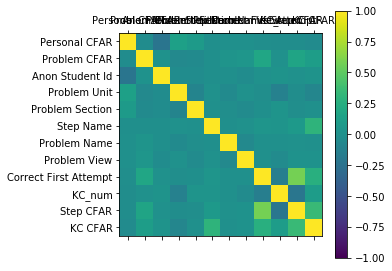

In [26]:
import matplotlib.pyplot as plt
import pandas
import numpy

names = ['Personal CFAR', 'Problem CFAR','Anon Student Id','Problem Unit', 'Problem Section', 'Step Name', 'Problem Name', 'Problem View', 'Correct First Attempt', 'KC_num', 'Step CFAR', 'KC CFAR']
correlations = x_df[names].corr()
# plot correlation matrix
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(222)
cax = ax.matshow(correlations, vmin=-1, vmax=1)
fig.colorbar(cax)
ticks = numpy.arange(0,len(names),1)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(names)
ax.set_yticklabels(names)
plt.savefig('./1.jpg')
plt.show()